#### Setup

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Imports
from ast import literal_eval

import torch
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import torch.nn.functional as f
from matplotlib.pyplot import figure
from matrepr import mprint
from pydmd import BOPDMD, DMD, HAVOK, HODMD, FbDMD, HankelDMD, OptDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
from safetensors.torch import load_model
from torchinfo import summary

from algo.embedding import dehankel, hankel
from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from models.perceptron import MLP
from saved_weights import parser

In [17]:
torch.set_printoptions(sci_mode=True)

In [18]:
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"
%matplotlib inline

#### Model & Dataset

In [19]:
HIDDEN = 5

In [20]:
file_path = "../saved_weights/model.safetensors"
metadata = parser.safetensors_metadata_parser(file_path=file_path)

model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
load_model(model, file_path, device="cuda:0")

model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=False)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=2, bias=False)
  )
)

In [21]:
PROBLEM = metadata["dataset"]
NUM_SAMPLES = 500
NUM_GAUSS_FEATURES = 0

SAMPLE_SIZE = 2

In [22]:
# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(size=NUM_SAMPLES)

elif PROBLEM == "rectangular":
    dataset = RectangularDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
else:
    raise NotImplementedError()

In [23]:
all_indices = np.arange(NUM_SAMPLES)
train_indices = np.random.choice(
    dataset.features.shape[0], size=SAMPLE_SIZE, replace=False
)
test_indices = np.random.choice(
    np.setdiff1d(all_indices, train_indices), size=SAMPLE_SIZE, replace=False
)

In [24]:
print("Train Indices")
mprint(train_indices)

print("Test Indices")
mprint(test_indices)

Train Indices
<length=2, 2 'int64' elements, array>
[102, 159]
Test Indices
<length=2, 2 'int64' elements, array>
[49, 368]


In [25]:
mprint(dataset.features[train_indices, :])

<2×2, 'torch.float32' elements, torch.strided>
┌                 ┐
│ 0.3216  0.09229 │
│ 0.2464  0.8191  │
└                 ┘


#### Get Activations

In [26]:
# LAYERS = [model.features[2]]
PREHOOK_LAYER = [model.features[1]]
LAYERS = [model.features[2], model.features[3]]

In [27]:
def getActivation(name, activation_dict):
    # the hook signature
    def hook(model, input, output):
        activation_dict[name] = output.detach()

    return hook

In [28]:
# Dictionary to store activations
activation_dict = {}

# Setup hook name
pre_hook_name = "pre_layer"
hook_name = "layer"

# Register the hook
pre_hook = PREHOOK_LAYER[-1].register_forward_hook(
    getActivation(pre_hook_name, activation_dict)
)
hook = LAYERS[-1].register_forward_hook(getActivation(hook_name, activation_dict))

# Feed inputs
out = model(dataset.features)

# Remove hook
pre_hook.remove()
hook.remove()

# Extract activations from
pre_hook_act = activation_dict[pre_hook_name]
hook_act = activation_dict[hook_name]


print("Prehook")
mprint(pre_hook_act[train_indices, :])
print("Activations")
mprint(hook_act[train_indices, :])

Prehook
<2×5, 'torch.float32' elements, torch.strided>
┌                                  ┐
│ 0.1847  0.3997  0  1.228  0.8394 │
│ 1.356     0     0    0    2.064  │
└                                  ┘
Activations
<2×5, 'torch.float32' elements, torch.strided>
┌                                    ┐
│ 4.247    0    3.489     0      0   │
│ 0.3754  1.68  0.1823  4.854  2.193 │
└                                    ┘


#### Layer Looping 

In [29]:
NUM_ITERATIONS = 4

In [30]:
def iterate_layer(inputs, layers, num_iterations):
    # Initialize the input tensor
    input_tensor = inputs.clone()

    # List to store the outputs at each iteration
    outputs = []

    # Loop for the specified number of iterations
    with torch.no_grad():
        for _ in range(num_iterations):
            # Pass the input through the layers
            for layer in layers:
                input_tensor = layer(input_tensor)

            # Store the output
            outputs.append(input_tensor.detach().clone())

    return outputs

In [31]:
train_looping_inputs = hook_act[train_indices, :]

# Should be only one sample from the activations you grabbed
# This is what will be looped into the layer
# Should match activation above
mprint(train_looping_inputs)

<2×5, 'torch.float32' elements, torch.strided>
┌                                    ┐
│ 4.247    0    3.489     0      0   │
│ 0.3754  1.68  0.1823  4.854  2.193 │
└                                    ┘


In [32]:
def interleave_rows(matrix, samples):
    """
    Reshapes a PyTorch tensor by interleaving rows in groups of 'samples'.

    Args:
        matrix (torch.Tensor): The input tensor of shape (N, T).
        samples (int): Number of rows to interleave in each group.

    Returns:
        torch.Tensor: The reshaped tensor of shape (N / samples, T * samples).
    """
    N, T = matrix.shape

    # Error handling for non-divisibility
    if N % samples != 0:
        raise ValueError("Number of rows (N) must be divisible by 'samples'.")

    # Group rows and concatenate horizontally
    interleaved = torch.cat([matrix[i::samples] for i in range(samples)], dim=1)

    # Reshape to final dimensions
    return interleaved.view(N // samples, T * samples)

In [33]:
model.eval()
loop_outputs = iterate_layer(
    inputs=train_looping_inputs,
    layers=LAYERS,
    num_iterations=NUM_ITERATIONS,
)
# train_states = torch.cat(
#     (dataset.features[train_indices, :], train_looping_inputs, torch.cat(loop_outputs))
# )
train_states = torch.cat(
    (pre_hook_act[train_indices, :], train_looping_inputs, torch.cat(loop_outputs))
)
train_states = interleave_rows(train_states, SAMPLE_SIZE)
mprint(train_states)

<6×10, 'torch.float32' elements, torch.strided>
┌                                                                            ┐
│ 0.1847  0.3997    0     1.228  0.8394  1.356     0      0       0    2.064 │
│ 4.247     0     3.489     0      0     0.3754  1.68   0.1823  4.854  2.193 │
│ 0.8556    0       0     1.999  5.798   9.099   6.853  6.837     0      0   │
│   0     15.37   0.1155  8.408    0     6.516   11.21    0       0    9.478 │
│ 32.51   16.45    20.5     0      0     3.813   44.5     0     3.38   1.94  │
│ 6.364   49.12     0       0    27.61   56.73   53.88  28.32     0      0   │
└                                                                            ┘


#### Visualize

In [34]:
mprint(train_states.T)

<10×6, 'torch.float32' elements, torch.strided>
┌                                              ┐
│ 0.1847  4.247   0.8556    0     32.51  6.364 │
│ 0.3997    0       0     15.37   16.45  49.12 │
│   0     3.489     0     0.1155  20.5     0   │
│ 1.228     0     1.999   8.408     0      0   │
│ 0.8394    0     5.798     0       0    27.61 │
│ 1.356   0.3754  9.099   6.516   3.813  56.73 │
│   0      1.68   6.853   11.21   44.5   53.88 │
│   0     0.1823  6.837     0       0    28.32 │
│   0     4.854     0       0     3.38     0   │
│ 2.064   2.193     0     9.478   1.94     0   │
└                                              ┘


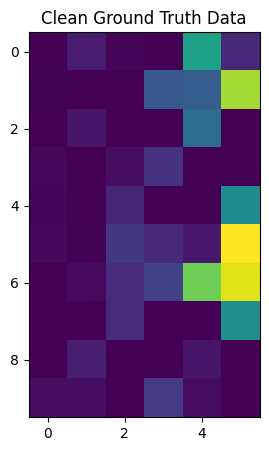

In [35]:
fig = plt.figure(figsize=(10, 5))
plt.title("Clean Ground Truth Data")
plt.imshow(train_states.T)
plt.show()

#### DMD

In [1127]:
DELAY_INT = 2
SVD_RANK = 3

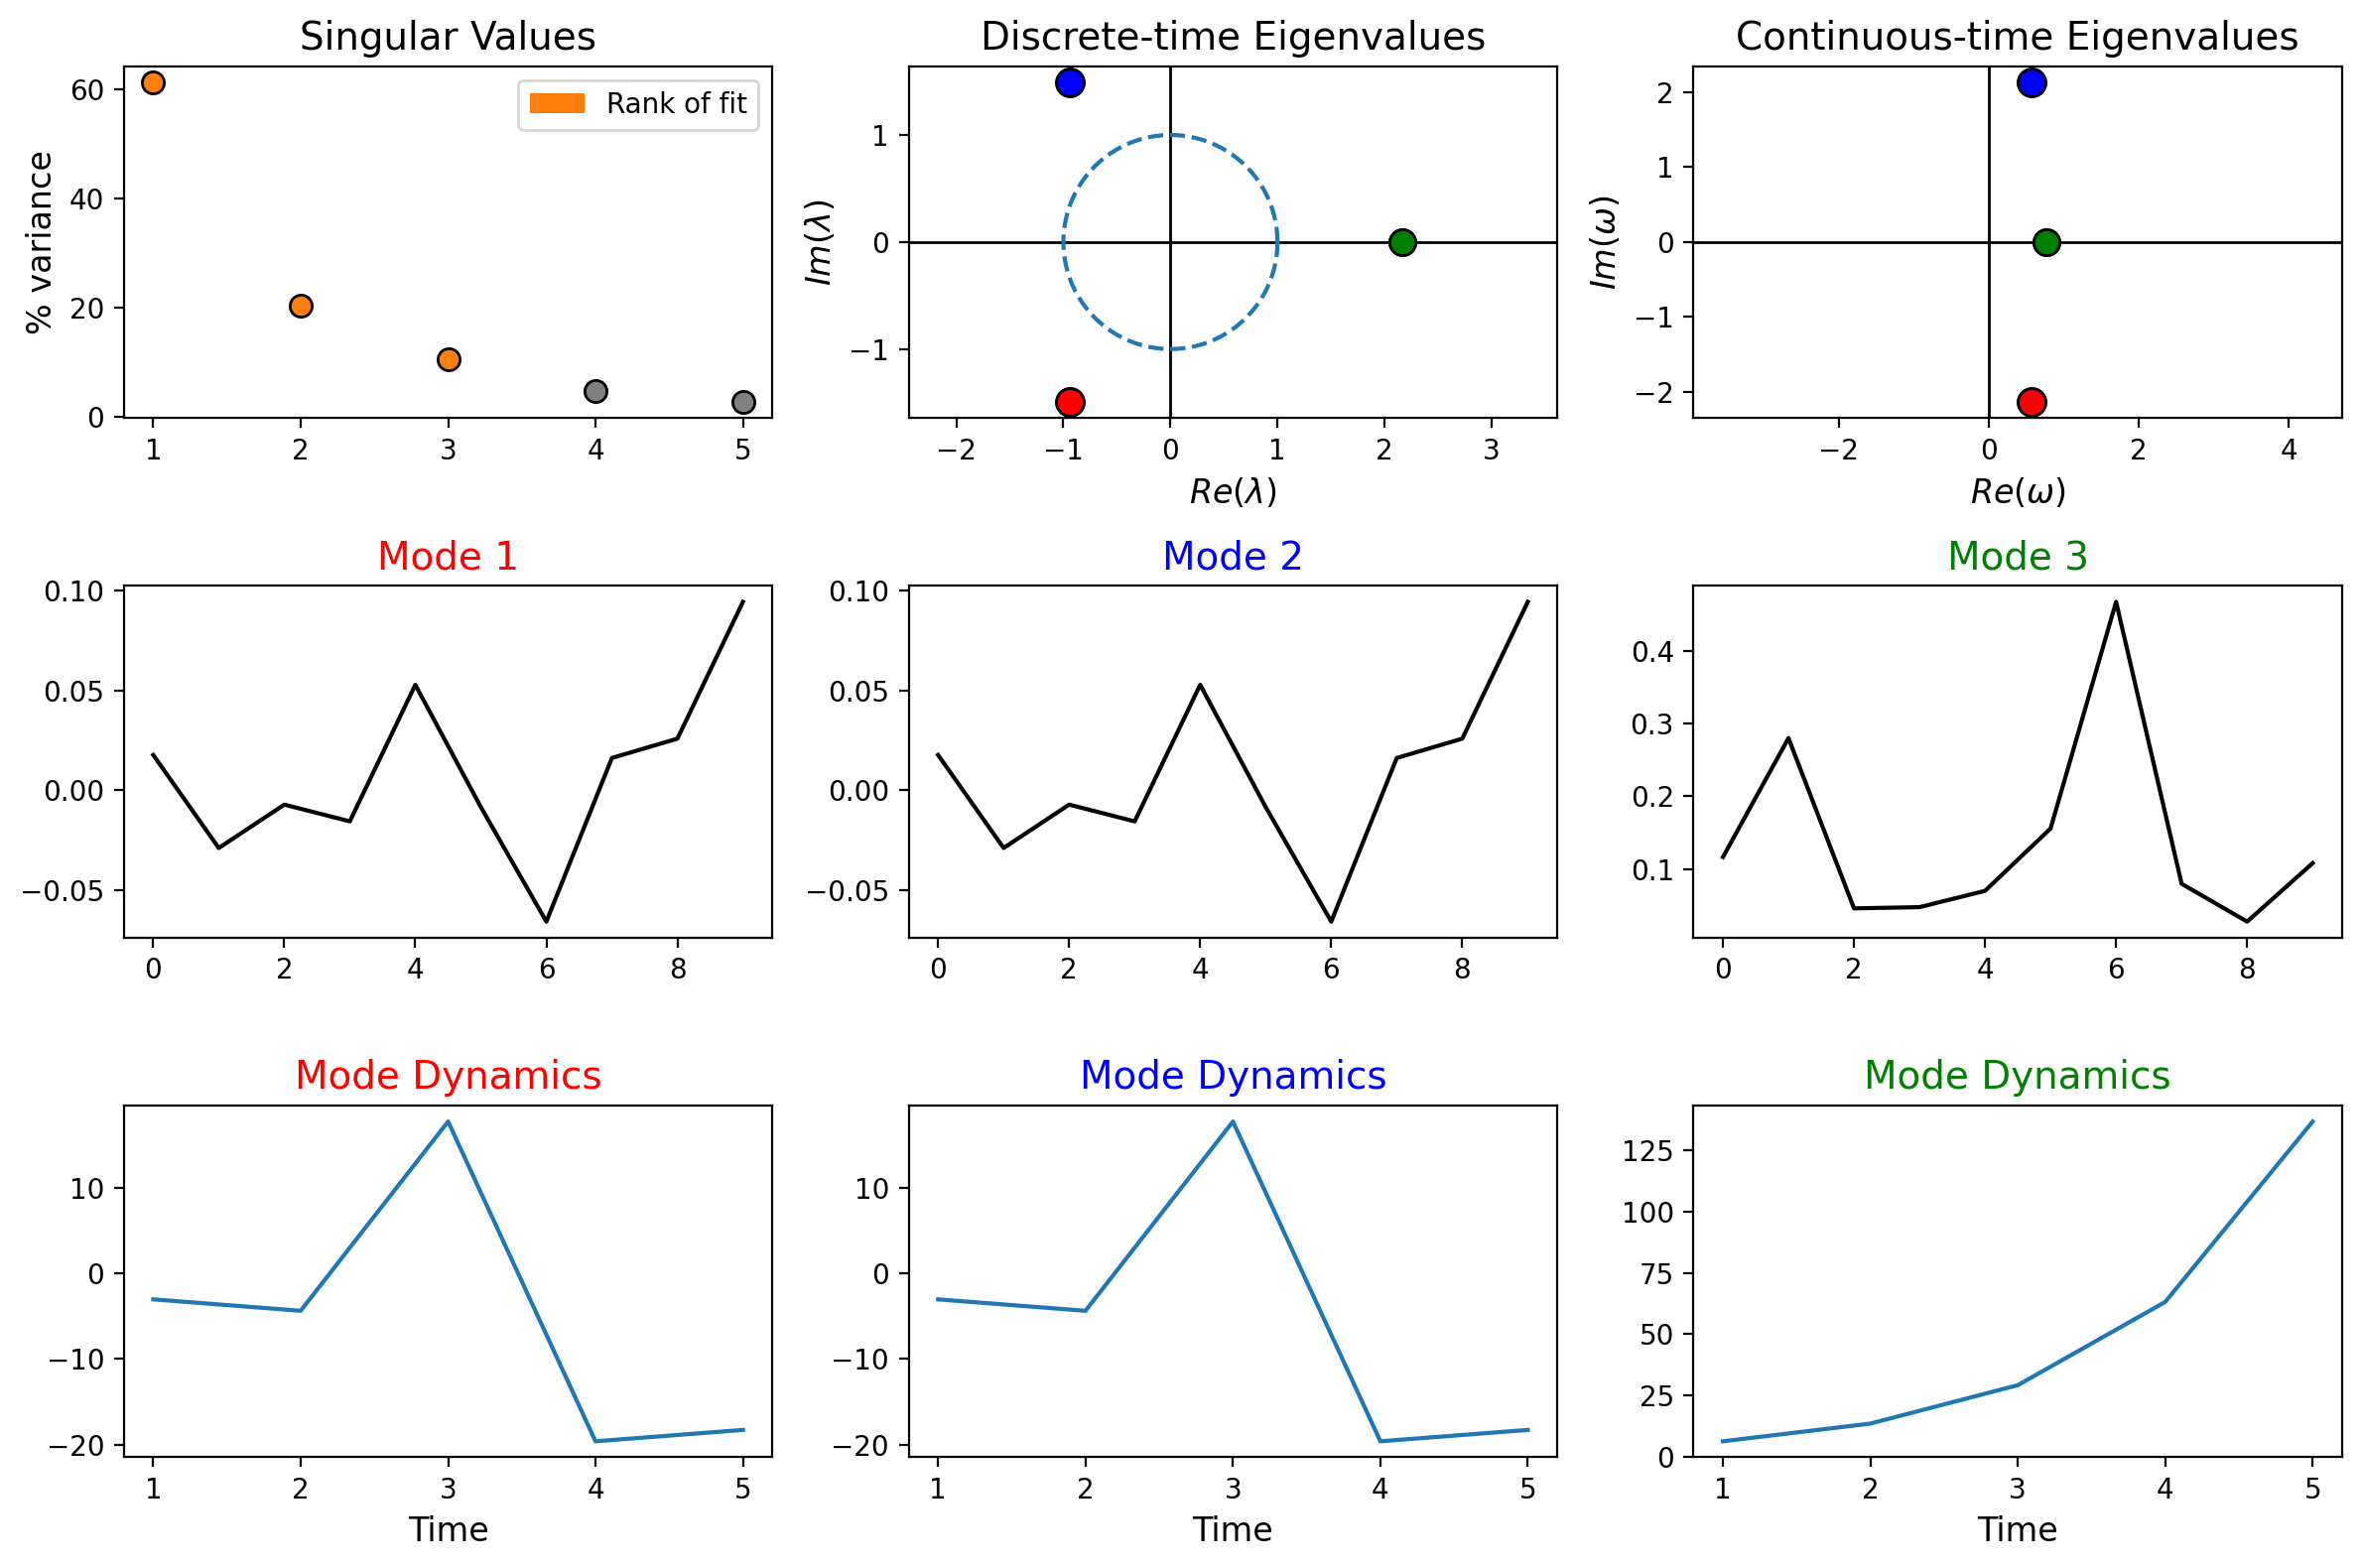

In [1128]:
dmd = BOPDMD(
    svd_rank=SVD_RANK,
    num_trials=10,
    # eig_constraints={"stable"},
    compute_A=True,
)
delay_dmd = hankel_preprocessing(dmd, d=DELAY_INT)
t = np.linspace(1, train_states.shape[0], train_states.shape[0])
delay_t = t[: -DELAY_INT + 1]
delay_dmd.fit(train_states.numpy().T, t=delay_t)
plot_summary(delay_dmd, d=DELAY_INT)

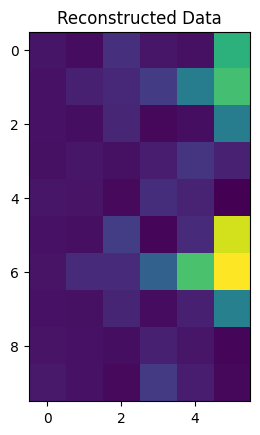

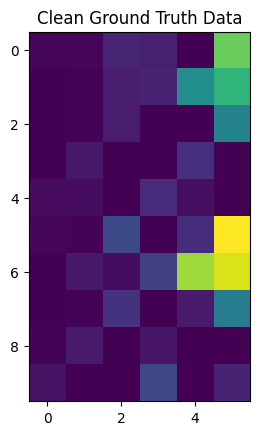

In [1129]:
plt.title("Reconstructed Data")
plt.imshow(delay_dmd.reconstructed_data.real)
plt.show()
plt.title("Clean Ground Truth Data")
plt.imshow(train_states.T)
plt.show()

#### Verifying Training

In [1130]:
def forecast_from_state(dmd, x0, d, t):
    # Hankelize the initial state
    x0_hankel = hankel(x0, delays=d)

    modes = torch.from_numpy(dmd.modes)
    eigs = torch.from_numpy(dmd.eigs)

    # Project the Hankelized initial state onto the DMD modes
    b = torch.linalg.lstsq(modes, x0_hankel.type(torch.cdouble), rcond=None).solution

    # Forecast each individual state and store in a list
    x_hankel_list = []
    for i in range(len(t)):
        # Ensure correct broadcasting by adding a new axis to 'b'
        x_hankel_i = modes @ (b * torch.exp(eigs * t[i]).unsqueeze(1))
        x_hankel_list.append(x_hankel_i)

    # Stack the forecasted states horizontally to create a Hankelized matrix
    x_hankel = torch.hstack(x_hankel_list)

    # De-Hankelize the prediction to get back the original variables
    x = dehankel(x_hankel, HIDDEN)

    return x

In [1131]:
# Original looped training data
mprint(train_states.T)

<10×6, 'torch.float32' elements, torch.strided>
┌                                              ┐
│ 0.9495  0.7995  6.402  5.442  0.09905  47.44 │
│   0     0.3749  4.774  5.806   30.28   40.14 │
│   0     0.6879  4.814    0       0     27.58 │
│   0     4.052     0      0     8.233     0   │
│ 1.818   2.034     0    7.319   2.381     0   │
│ 1.195   0.7106  13.58    0     7.963   61.45 │
│   0     4.123   2.128  11.55   52.55   57.94 │
│   0     0.596   8.987    0     4.433    26   │
│ 0.6765  4.484     0    3.62      0       0   │
│ 2.675     0       0    13.11     0     6.211 │
└                                              ┘


In [1132]:
# Hankelize the matrix with delay
# Grab 0 column to show input into the DMD matrix
print("Hankel")
mprint(hankel(train_states.T, delays=DELAY_INT))

print("Truncating Hankel")
mprint(hankel(train_states.T, delays=DELAY_INT)[:HIDDEN, :1])

Hankel
<20×5, 'torch.float32' elements, torch.strided>
┌                                       ┐
│ 0.9495  0.7995  6.402  5.442  0.09905 │
│   0     0.3749  4.774  5.806   30.28  │
│   0     0.6879  4.814    0       0    │
│   0     4.052     0      0     8.233  │
│ 1.818   2.034     0    7.319   2.381  │
│   :       :       :      :       :    │
│ 0.7106  13.58     0    7.963   61.45  │
│ 4.123   2.128   11.55  52.55   57.94  │
│ 0.596   8.987     0    4.433    26    │
│ 4.484     0     3.62     0       0    │
│   0       0     13.11    0     6.211  │
└                                       ┘
Truncating Hankel
<5×1, 'torch.float32' elements, torch.strided>
┌        ┐
│ 0.9495 │
│   0    │
│   0    │
│   0    │
│ 1.818  │
└        ┘


In [1133]:
forecast = forecast_from_state(delay_dmd, train_states.T, DELAY_INT, [1])
mprint(forecast)

torch.Size([20, 3])
<5×8, 'torch.float32' elements, torch.strided>
┌                                                                      ┐
│ 0.2852   -0.02193   2.497     4.219   -10.31  -24.47  74.16   -35.85 │
│  2.049    3.923     4.813     7.629   22.58    59.3   71.09   208.4  │
│ -0.1642  -0.06338   1.564      1.9    -4.477  -9.861  32.46   -14.9  │
│ 0.4798    0.3556    0.7642   -0.1091  3.853   4.516   -2.603  23.77  │
│ 0.8159    1.203    -0.03083  -0.1113  11.15   10.06   -1.826  69.81  │
└                                                                      ┘


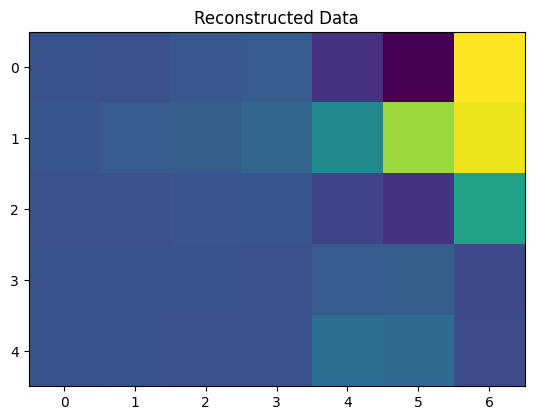

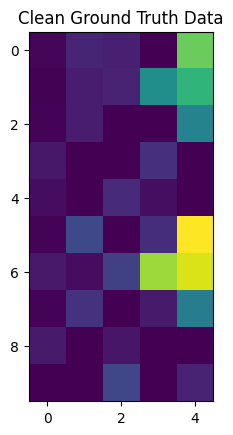

In [1134]:
plt.title("Reconstructed Data")
plt.imshow(forecast[:, :-1])
plt.show()
plt.title("Clean Ground Truth Data")
plt.imshow(train_states.T[:, 1:])
plt.show()

#### Testing

In [1135]:
test_indices = [44]

In [1136]:
test_looping_inputs = hook_act[test_indices, :]

model.eval()
loop_outputs = iterate_layer(
    inputs=test_looping_inputs,
    layers=LAYERS,
    num_iterations=NUM_ITERATIONS,
)
test_states = torch.cat(
    (pre_hook_act[test_indices, :], test_looping_inputs, torch.cat(loop_outputs))
)

In [1137]:
# Original looped training data
mprint(test_states.T)

<5×6, 'torch.float32' elements, torch.strided>
┌                                           ┐
│ 0.5413  3.702  2.681    0    35.65  14.64 │
│ 0.3957  1.294    0    14.02  24.89  61.78 │
│   0     2.991    0      0    23.57    0   │
│ 1.607     0      0    13.27    0      0   │
│ 1.705     0    5.267  1.705    0    30.05 │
└                                           ┘


In [1138]:
# Hankelize the matrix with delay
# Grab 0 column to show input into the DMD matrix
print("Hankel")
mprint(hankel(test_states.T, delays=DELAY_INT))

print("Truncating Hankel")
mprint(hankel(test_states.T, delays=DELAY_INT)[:HIDDEN, :1])

Hankel
<10×5, 'torch.float32' elements, torch.strided>
┌                                    ┐
│ 0.5413  3.702  2.681    0    35.65 │
│ 0.3957  1.294    0    14.02  24.89 │
│   0     2.991    0      0    23.57 │
│ 1.607     0      0    13.27    0   │
│ 1.705     0    5.267  1.705    0   │
│ 3.702   2.681    0    35.65  14.64 │
│ 1.294     0    14.02  24.89  61.78 │
│ 2.991     0      0    23.57    0   │
│   0       0    13.27    0      0   │
│   0     5.267  1.705    0    30.05 │
└                                    ┘
Truncating Hankel
<5×1, 'torch.float32' elements, torch.strided>
┌        ┐
│ 0.5413 │
│ 0.3957 │
│   0    │
│ 1.607  │
│ 1.705  │
└        ┘


In [1139]:
forecast = forecast_from_state(delay_dmd, test_states.T, DELAY_INT, [1])
mprint(forecast)

torch.Size([20, 3])


RuntimeError: torch.linalg.lstsq: input.size(-2) should match other.size(-2)

In [ ]:
forecast.shape

torch.Size([5, 6])

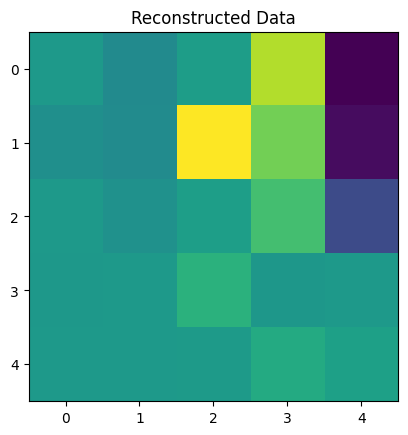

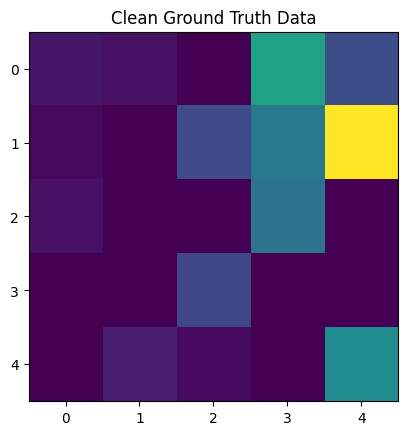

In [ ]:
plt.title("Reconstructed Data")
plt.imshow(forecast[:, :-1])
plt.show()
plt.title("Clean Ground Truth Data")
plt.imshow(test_states.T[:, 1:])
plt.show()